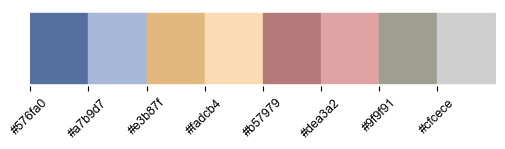

In [5]:
colors = ['#f08f92', '#9cbedb', '#a9d5a5']
colors = ['#e31a1c','#fc4e2a', '#fd8d3c', '#feb24c','#fed976']
color = ['#576fa0','#a7b9d7','#e3b87f','#fadcb4','#b57979','#dea3a2','#9f9f91','#cfcece']

import matplotlib.pyplot as plt

# 颜色列表（去掉错误的 ':#71B4E6'）
colors =['#f08f92', '#9cbedb', '#a9d5a5']
labels =['#f08f92', '#9cbedb', '#a9d5a5']
colors =['#576fa0','#a7b9d7','#e3b87f','#fadcb4','#b57979','#dea3a2','#9f9f91','#cfcece']
labels =['#576fa0','#a7b9d7','#e3b87f','#fadcb4','#b57979','#dea3a2','#9f9f91','#cfcece']
# 画出颜色方块
plt.figure(figsize=(6, 1))
for i, (color, label) in enumerate(zip(colors, labels)):
    plt.fill_between([i, i+1], 0, 1, color=color, label=label)

# 去除坐标轴
plt.xticks(range(len(colors)), labels, rotation=45)
plt.yticks([])
plt.xlim(0, len(colors))
plt.box(False)

# 显示颜色
plt.show()

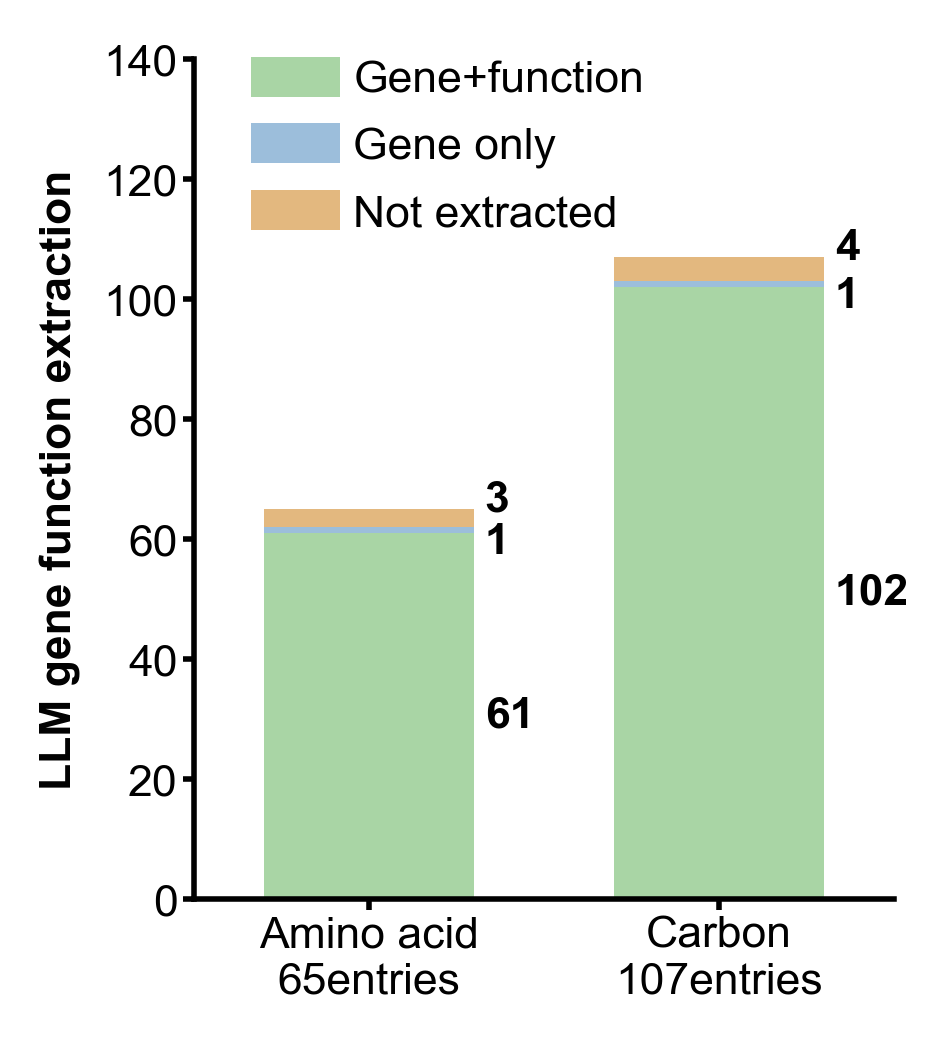

In [188]:
import matplotlib.pyplot as plt
import numpy as np

# Set slightly smaller figure size
plt.figure(figsize=(2.5, 3), dpi=400)  # 比原来稍微缩小，适合一页放三张
plt.rcParams.update({'font.size': 8})
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42

# Set axis style
plt.gca().spines['top'].set_linewidth(0)
plt.gca().spines['bottom'].set_linewidth(1)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['right'].set_linewidth(0)
plt.subplots_adjust(left=0.15, right=0.85, bottom=0.15, top=0.85)  # 稍微收紧一点，保证图内部元素不挤

# Example data
annotation_gene = [61, 102]
extracted_wihout_annotation_gene = [1, 1]
not_extracted_gene = [3, 4]

# Set colors
colors = ['#a9d5a5', '#9cbedb', '#e3b87f']
width = 0.6
x = np.arange(len(annotation_gene)) + 0.5

# Plot bars
bars1 = plt.bar(x, annotation_gene, width, color=colors[0], edgecolor='black', linewidth=0, label='Gene+function')
bars2 = plt.bar(x, extracted_wihout_annotation_gene, width, bottom=annotation_gene, color=colors[1], edgecolor='black', linewidth=0, label='Gene only')
bars3 = plt.bar(x, not_extracted_gene, width, bottom=np.array(annotation_gene) + np.array(extracted_wihout_annotation_gene), color=colors[2], edgecolor='black', linewidth=0, label='Not extracted')

# Add value labels
for i in range(len(x)):
    plt.text(x[i] + 0.33, annotation_gene[i] / 2, str(annotation_gene[i]),
             ha='left', va='center', fontsize=8, color='black', fontweight='bold')

    second_y = annotation_gene[i] + extracted_wihout_annotation_gene[i] / 2 - 2
    plt.text(x[i] + 0.33, second_y, str(extracted_wihout_annotation_gene[i]),
             ha='left', va='center', fontsize=8, color='black', fontweight='bold')

    total_height = annotation_gene[i] + extracted_wihout_annotation_gene[i]
    third_y = total_height + not_extracted_gene[i] + 1.5
    plt.text(x[i] + 0.33, third_y, str(not_extracted_gene[i]),
             ha='left', va='center', fontsize=8, color='black', fontweight='bold')

# Axis parameters
plt.tick_params(axis='y', direction='out', width=1, which='both', length=2, pad=1)
plt.tick_params(axis='x', direction='out', width=1, which='both', length=2, pad=1)
plt.ylim(0, 140)
plt.xlim(0, len(annotation_gene))

# Axis labels
plt.xticks(x, ['Amino acid\n65entries', 'Carbon\n107entries'], fontsize=8)
plt.yticks(fontsize=8)
plt.ylabel('LLM gene function extraction', fontsize=8, fontweight='bold')

# Legend
handles, labels = plt.gca().get_legend_handles_labels()
label_order = ['Gene+function', 'Gene only', 'Not extracted']
ordered = sorted(zip(handles, labels), key=lambda x: label_order.index(x[1]))
ordered_handles, ordered_labels = zip(*ordered)

plt.legend(
    ordered_handles, ordered_labels,
    fontsize=8,
    bbox_to_anchor=(0.7, 1.05), loc='upper right',
    frameon=False, handleheight=1, handletextpad=0.3
)

plt.savefig(r"D:\Projects\Human_gene\Info_Extration\Picture\all_figs\fig2a.pdf", transparent=True, dpi=400, bbox_inches='tight')
plt.show()


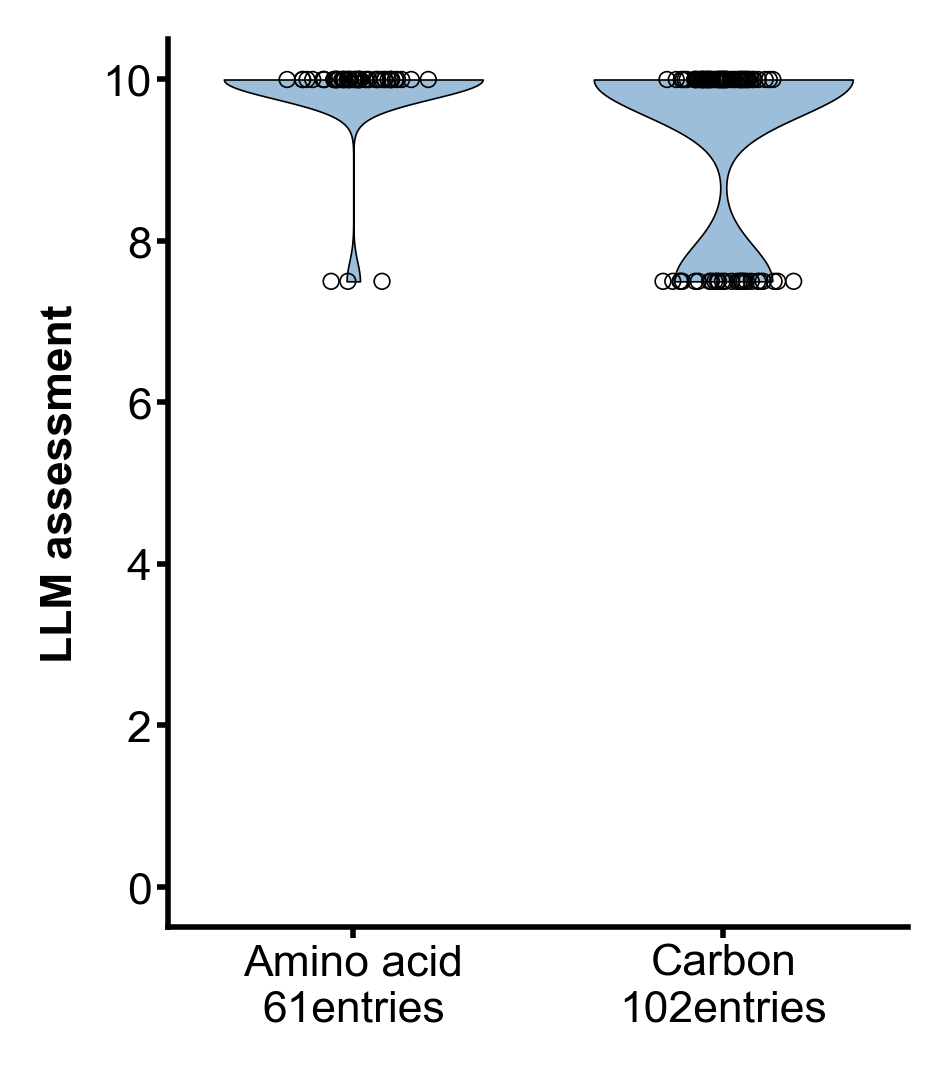

In [154]:
import numpy as np
import matplotlib.pyplot as plt

# Data preparation
aminoacid_score = [10]*58+[7.5]*3
carbon_score = [10]*74+[7.5]*28
data = [aminoacid_score, carbon_score]

# Set general parameters with larger size and fonts
plt.figure(figsize=(2.5, 3), dpi=400)  # Increased from (1.5, 2)
plt.rcParams.update({'font.size': 8})  # Changed from 9 to 8
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42

# Set axis style
plt.gca().spines['top'].set_linewidth(0)
plt.gca().spines['bottom'].set_linewidth(1)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['right'].set_linewidth(0)
plt.subplots_adjust(left=0.13, right=0.87, bottom=0.13, top=0.87)

# Create violin plot
parts = plt.violinplot(data,
                       showmeans=False,
                       showmedians=False,
                       showextrema=False,
                       widths=0.7)

# Set violin plot colors and borders
colors = ['#9cbedb', '#9cbedb', '#9cbedb']

for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors[i])
    pc.set_edgecolor('black')
    pc.set_linewidth(0.3)
    pc.set_alpha(1)

# Add jittered scatter points
jitter_strength = 0.08
for i, scores in enumerate(data):
    x_jitter = np.random.normal(i + 1, jitter_strength, size=len(scores))
    plt.scatter(x_jitter, scores, color='none', edgecolor='black', 
                alpha=1, s=8, linewidth=0.3)  # Increased s from 4 to 8

# Set axis parameters
plt.tick_params(axis='y', direction='out', width=1, which='both', length=2, pad=1)
plt.tick_params(axis='x', direction='out', width=1, which='both', length=2, pad=1)

# Set axis limits
plt.ylim(-0.5, 10.5)
plt.xlim(0.5, len(data)+0.5)

# Set labels with larger font
plt.xticks([1,2], ['Amino acid\n61entries', 'Carbon\n102entries'], rotation=0, fontsize=8)  # Changed from 6 to 8
plt.yticks(fontsize=8)  # Changed from 6 to 8
plt.ylabel('LLM assessment', fontsize=8, fontweight='bold')  # Changed from 6 to 8

plt.savefig(r"D:\Projects\Human_gene\Info_Extration\Picture\all_figs\fig2b.pdf", transparent = True, dpi=400, bbox_inches = 'tight')
plt.show()

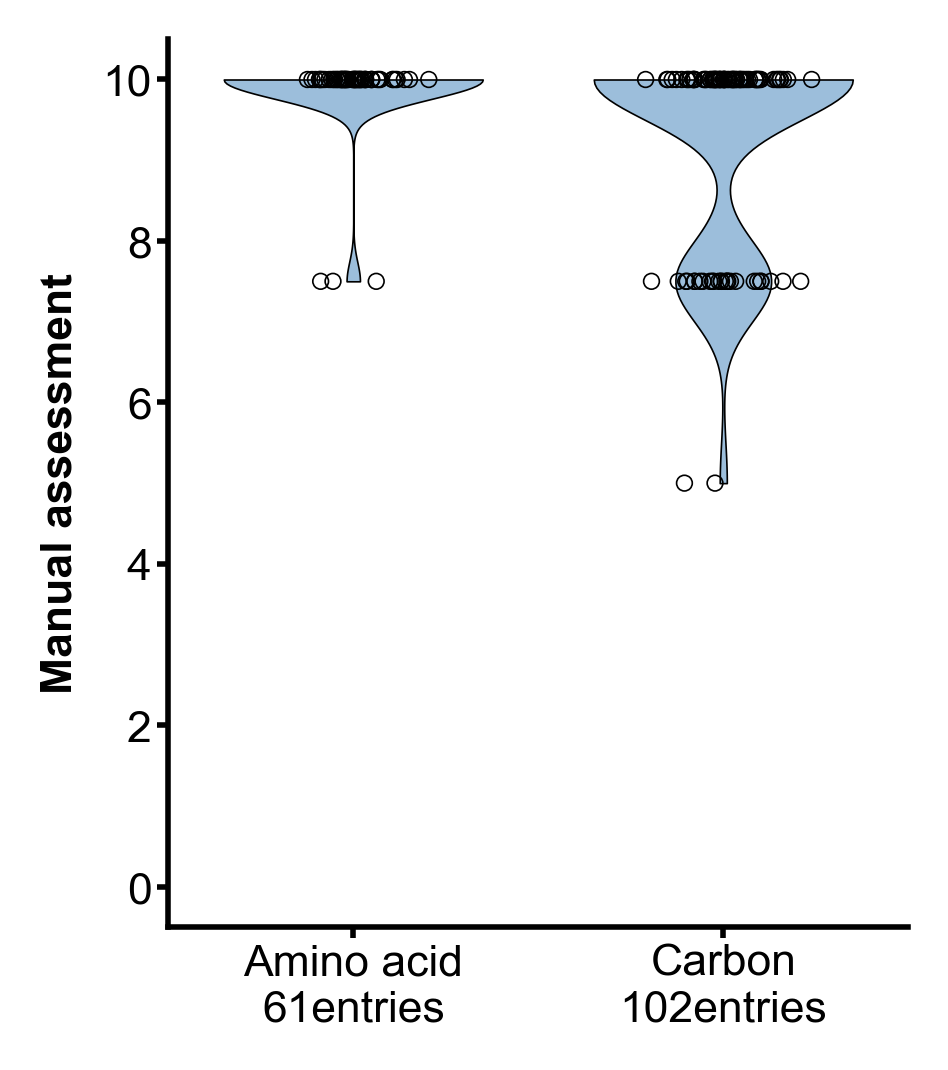

In [157]:
import numpy as np
import matplotlib.pyplot as plt

# Data preparation
aminoacid_score = [10]*58+[7.5]*3
carbon_score = [10]*73+[7.5]*27+[5]*2
data = [aminoacid_score, carbon_score]

# Set general parameters with larger size and fonts
plt.figure(figsize=(2.5, 3), dpi=400)  # Increased from (1.5, 2)
plt.rcParams.update({'font.size': 8})  # Changed from 9 to 8
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42

# Set axis style
plt.gca().spines['top'].set_linewidth(0)
plt.gca().spines['bottom'].set_linewidth(1)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['right'].set_linewidth(0)
plt.subplots_adjust(left=0.13, right=0.87, bottom=0.13, top=0.87)

# Create violin plot
parts = plt.violinplot(data,
                       showmeans=False,
                       showmedians=False,
                       showextrema=False,
                       widths=0.7)

# Set violin plot colors and borders
colors = ['#9cbedb', '#9cbedb', '#9cbedb']

for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors[i])
    pc.set_edgecolor('black')
    pc.set_linewidth(0.3)
    pc.set_alpha(1)

# Add jittered scatter points
jitter_strength = 0.08
for i, scores in enumerate(data):
    x_jitter = np.random.normal(i + 1, jitter_strength, size=len(scores))
    plt.scatter(x_jitter, scores, color='none', edgecolor='black', 
                alpha=1, s=8, linewidth=0.3)  # Increased s from 4 to 8

# Set axis parameters
plt.tick_params(axis='y', direction='out', width=1, which='both', length=2, pad=1)
plt.tick_params(axis='x', direction='out', width=1, which='both', length=2, pad=1)

# Set axis limits
plt.ylim(-0.5, 10.5)
plt.xlim(0.5, len(data)+0.5)

# Set labels with larger font
plt.xticks([1,2], ['Amino acid\n61entries', 'Carbon\n102entries'], rotation=0, fontsize=8)  # Changed from 6 to 8
plt.yticks(fontsize=8)  # Changed from 6 to 8
plt.ylabel('Manual assessment', fontsize=8, fontweight='bold')  # Changed from 6 to 8

plt.savefig(r"D:\Projects\Human_gene\Info_Extration\Picture\all_figs\fig2c.pdf", transparent = True, dpi=400, bbox_inches = 'tight')
plt.show()

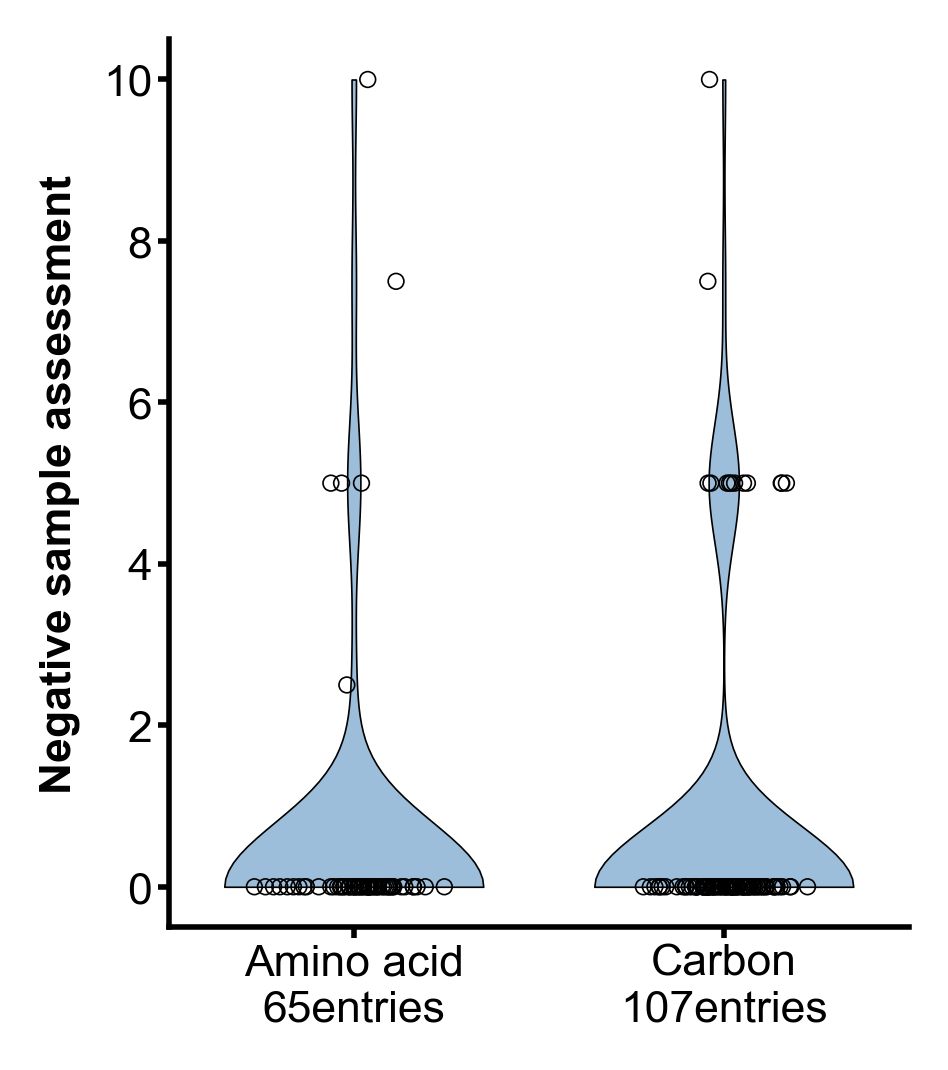

In [158]:
import numpy as np
import matplotlib.pyplot as plt

# Data preparation
aminoacid_score = [0]*59+[2.5]*1+[5]*3+[7.5]*1+[10]*1
carbon_score = [0]*94+[2.5]*0+[5]*11+[7.5]*1+[10]*1
data = [aminoacid_score, carbon_score]

# Set general parameters with larger size and fonts
plt.figure(figsize=(2.5, 3), dpi=400)  # Increased from (1.5, 2)
plt.rcParams.update({'font.size': 8})  # Changed from 9 to 8
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42

# Set axis style
plt.gca().spines['top'].set_linewidth(0)
plt.gca().spines['bottom'].set_linewidth(1)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['right'].set_linewidth(0)
plt.subplots_adjust(left=0.13, right=0.87, bottom=0.13, top=0.87)

# Create violin plot
parts = plt.violinplot(data,
                       showmeans=False,
                       showmedians=False,
                       showextrema=False,
                       widths=0.7)

# Set violin plot colors and borders
colors = ['#9cbedb', '#9cbedb', '#9cbedb']

for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors[i])
    pc.set_edgecolor('black')
    pc.set_linewidth(0.3)
    pc.set_alpha(1)

# Add jittered scatter points
jitter_strength = 0.1  # Slightly increased jitter for larger plot
for i, scores in enumerate(data):
    x_jitter = np.random.normal(i + 1, jitter_strength, size=len(scores))
    plt.scatter(x_jitter, scores, color='none', edgecolor='black', 
                alpha=1, s=8, linewidth=0.3)  # Increased s from 4 to 8

# Set axis parameters
plt.tick_params(axis='y', direction='out', width=1, which='both', length=2, pad=1)
plt.tick_params(axis='x', direction='out', width=1, which='both', length=2, pad=1)

# Set axis limits
plt.ylim(-0.5, 10.5)
plt.xlim(0.5, len(data)+0.5)

# Set labels with larger font
plt.xticks([1,2], ['Amino acid\n65entries', 'Carbon\n107entries'], 
           rotation=0, fontsize=8)  # Changed from 6 to 8, added gene counts
plt.yticks(fontsize=8)  # Changed from 6 to 8
plt.ylabel('Negative sample assessment', fontsize=8, fontweight='bold')  # Changed from 6 to 8

plt.savefig(r"D:\Projects\Human_gene\Info_Extration\Picture\all_figs\fig2d.pdf", transparent = True, dpi=400, bbox_inches = 'tight')
plt.show()

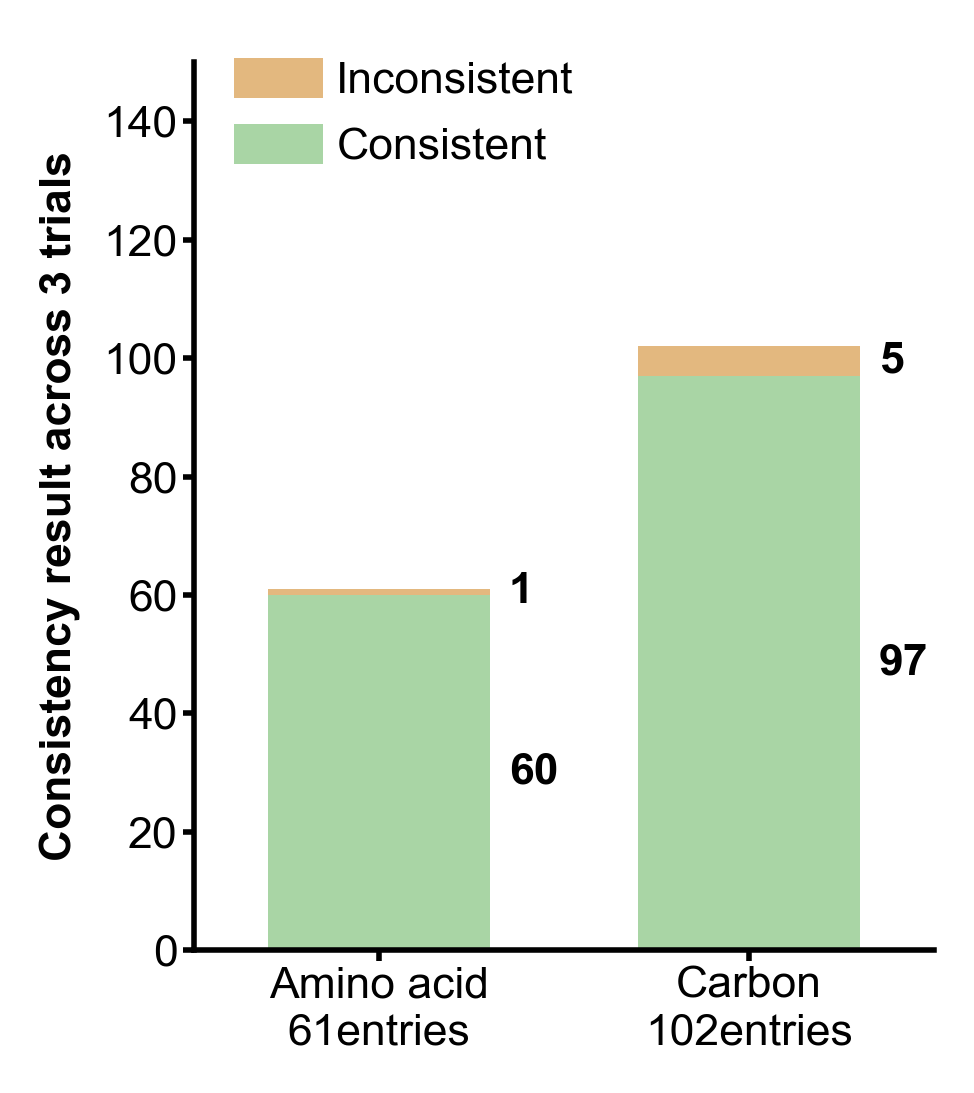

In [159]:
import matplotlib.pyplot as plt
import numpy as np

# Set general parameters with larger size and fonts
plt.figure(figsize=(2.5, 3), dpi=400)  # Increased from (1.5, 2)
plt.rcParams.update({'font.size': 8})  # Changed from 9 to 8
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42

# Set axis style
plt.gca().spines['top'].set_linewidth(0)
plt.gca().spines['bottom'].set_linewidth(1)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['right'].set_linewidth(0)
plt.subplots_adjust(left=0.13, right=0.87, bottom=0.13, top=0.87)

# Sample data (three components for each group)
consistent = [60, 97]  
inconsistent = [1, 5]  

# Set colors for each component
colors = ['#a9d5a5', '#e3b87f']

# Set bar width
width = 0.6

# Create x positions
x = np.arange(len(consistent)) + 0.5

# Plot stacked bars
bars1 = plt.bar(x, consistent, width, color=colors[0], edgecolor='black', linewidth=0, label='Consistent')
bars2 = plt.bar(x, inconsistent, width, bottom=consistent, color=colors[1], edgecolor='black', linewidth=0, label='Inconsistent')

# Add values on each bar
for i in range(len(x)):
    # First component
    plt.text(x[i] + 0.35, consistent[i] / 2, str(consistent[i]), 
             ha='left', va='center', fontsize=8, color='black', fontweight='bold')  # fontsize 6->8
    # Second component
    plt.text(x[i] + 0.35, consistent[i] + inconsistent[i] / 2, str(inconsistent[i]), 
             ha='left', va='center', fontsize=8, color='black', fontweight='bold')  # fontsize 6->8

# Set axis parameters
plt.tick_params(axis='y', direction='out', width=1, which='both', length=2, pad=1)
plt.tick_params(axis='x', direction='out', width=1, which='both', length=2, pad=1)

# Set axis limits
plt.ylim(0, 150)
plt.xlim(0, len(consistent))

# Set x-axis labels
plt.xticks(x, ['Amino acid\n61entries', 'Carbon\n102entries'], 
           rotation=0, fontsize=8)  # fontsize 6->8, updated counts
plt.yticks(fontsize=8)  # fontsize 6->8

# Set y-axis label
plt.ylabel('Consistency result across 3 trials', fontsize=8, fontweight='bold')  # fontsize 6->8

# Add legend
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(
    handles[::-1], labels[::-1],
    fontsize=8,  # fontsize 6->8
    bbox_to_anchor=(0, 1.05), loc='upper left', frameon=False,
    handleheight=1,
    handletextpad=0.3,
)

plt.savefig(r"D:\Projects\Human_gene\Info_Extration\Picture\all_figs\fig2e.pdf", transparent = True, dpi=400, bbox_inches = 'tight')
plt.show()

In [284]:
# import matplotlib.pyplot as plt
# import numpy as np

# # 设置通用参数
# plt.figure(figsize=(1.5, 2), dpi=400)
# plt.rcParams.update({'font.size': 9})
# plt.rcParams['font.family'] = 'Arial'
# plt.rcParams['pdf.fonttype'] = 42

# # 设置轴样式
# plt.gca().spines['top'].set_linewidth(0)
# plt.gca().spines['bottom'].set_linewidth(1)
# plt.gca().spines['left'].set_linewidth(1)
# plt.gca().spines['right'].set_linewidth(0)
# plt.subplots_adjust(left=0.13, right=0.87, bottom=0.13, top=0.87)

# # 示例数据（每组的三个组成部分）
# human_true = [111, 68]  
# human_false = [1, 0]  
# human_notsure = [1, 1]  

# # 设置每个部分的颜色
# colors = ['#f08f92', '#9cbedb', '#a9d5a5']
# colors = ['#e31a1c', '#fd8d3c', '#fed976']
# # 设置柱状图的宽度
# width = 0.6

# # 创建 x 轴位置
# x = np.arange(len(annotation_gene)) + 0.5  # 生成 x 轴坐标

# # 绘制堆积柱状图
# bars1 = plt.bar(x, human_true, width, color=colors[0], edgecolor='black', linewidth=0, label='True')
# bars2 = plt.bar(x, human_false, width, bottom=human_true, color=colors[1], edgecolor='black', linewidth=0, label='Not sure')
# bars3 = plt.bar(x, human_notsure, width, bottom=np.array(human_true) + np.array(human_false), color=colors[2], edgecolor='black', linewidth=0, label='False')

# # 设置坐标轴参数
# plt.tick_params(axis='y', direction='out', width=1, which='both', length=2, pad=1)
# plt.tick_params(axis='x', direction='out', width=1, which='both', length=2, pad=1)

# # 设置坐标轴范围
# plt.ylim(0, 140)
# plt.xlim(0, len(annotation_gene))

# # 设置 x 轴标签
# plt.xticks(x, ['Amino acid\n(160 papers)', 'Carbon\n(92 papers)'], rotation=0, fontsize=6)
# plt.yticks(fontsize=6)

# # 设置 y 轴标签
# plt.ylabel('Counts of gene', fontsize=6, fontweight='bold')

# # 添加图例
# # 获取当前图例的句柄和标签
# handles, labels = plt.gca().get_legend_handles_labels()
# # 颠倒顺序
# plt.legend(
#     handles[::-1], labels[::-1],
#     fontsize=6, 
#     bbox_to_anchor=(1, 1.05), loc='upper right', frameon=False,
#     # handlelength=1.5,  # 控制色块的长度
#     handleheight=1,  # 控制色块的高度
#     handletextpad=0.3,  # 控制色块和文本之间的距离
# )
# # 显示图形
# plt.show()

In [285]:
# import matplotlib.pyplot as plt
# import numpy as np

# # 设置通用参数
# plt.figure(figsize=(1.5, 2), dpi=400)
# plt.rcParams.update({'font.size': 9})
# plt.rcParams['font.family'] = 'Arial'
# plt.rcParams['pdf.fonttype'] = 42

# # 设置轴样式
# plt.gca().spines['top'].set_linewidth(0)
# plt.gca().spines['bottom'].set_linewidth(1)
# plt.gca().spines['left'].set_linewidth(1)
# plt.gca().spines['right'].set_linewidth(0)
# plt.subplots_adjust(left=0.13, right=0.87, bottom=0.13, top=0.87)

# # 示例数据（每组的三个组成部分）
# ai_socre_10 = [95, 60]  
# ai_socre_75 = [0, 1]  
# ai_socre_5 = [11, 3]  
# ai_socre_25 = [1, 1]  
# ai_socre_0 = [1, 1]  

# # 设置每个部分的颜色
# colors = ['#f08f92', '#9cbedb', '#a9d5a5']
# colors = ['#e31a1c','#fc4e2a', '#fd8d3c', '#feb24c','#fed976']

# # 设置柱状图的宽度
# width = 0.6

# # 创建 x 轴位置
# x = np.arange(len(annotation_gene)) + 0.5  # 生成 x 轴坐标

# # 绘制堆积柱状图
# bars1 = plt.bar(x, ai_socre_10, width, color=colors[0], edgecolor='black', linewidth=0, label='10')
# bars2 = plt.bar(x, ai_socre_75, width, bottom=ai_socre_10, color=colors[1], edgecolor='black', linewidth=0, label='7.5')
# bars3 = plt.bar(x, ai_socre_5, width, bottom=np.array(ai_socre_10) + np.array(ai_socre_75), color=colors[2], edgecolor='black', linewidth=0, label='5')
# bars4 = plt.bar(x, ai_socre_25, width, bottom=np.array(ai_socre_10) + np.array(ai_socre_75) + np.array(ai_socre_5), color=colors[3], edgecolor='black', linewidth=0, label='2.5')
# bars5 = plt.bar(x, ai_socre_0, width, bottom=np.array(ai_socre_10) + np.array(ai_socre_75) + np.array(ai_socre_5) + np.array(ai_socre_25), color=colors[4], edgecolor='black', linewidth=0, label='0')

# # 设置坐标轴参数
# plt.tick_params(axis='y', direction='out', width=1, which='both', length=2, pad=1)
# plt.tick_params(axis='x', direction='out', width=1, which='both', length=2, pad=1)

# # 设置坐标轴范围
# plt.ylim(0, 140)
# plt.xlim(0, len(annotation_gene))

# # 设置 x 轴标签
# plt.xticks(x, ['Amino acid\n(160 papers)', 'Carbon\n(92 papers)'], rotation=0, fontsize=6)
# plt.yticks(fontsize=6)

# # 设置 y 轴标签
# plt.ylabel('Counts of gene', fontsize=6, fontweight='bold')

# # 添加图例
# # 获取当前图例的句柄和标签
# handles, labels = plt.gca().get_legend_handles_labels()
# # 颠倒顺序
# plt.legend(
#     handles[::-1], labels[::-1],
#     fontsize=6, 
#     bbox_to_anchor=(1, 1.05), loc='upper right', frameon=False,
#     # handlelength=1.5,  # 控制色块的长度
#     handleheight=1,  # 控制色块的高度
#     handletextpad=0.3,  # 控制色块和文本之间的距离
# )
# # 显示图形
# plt.show()

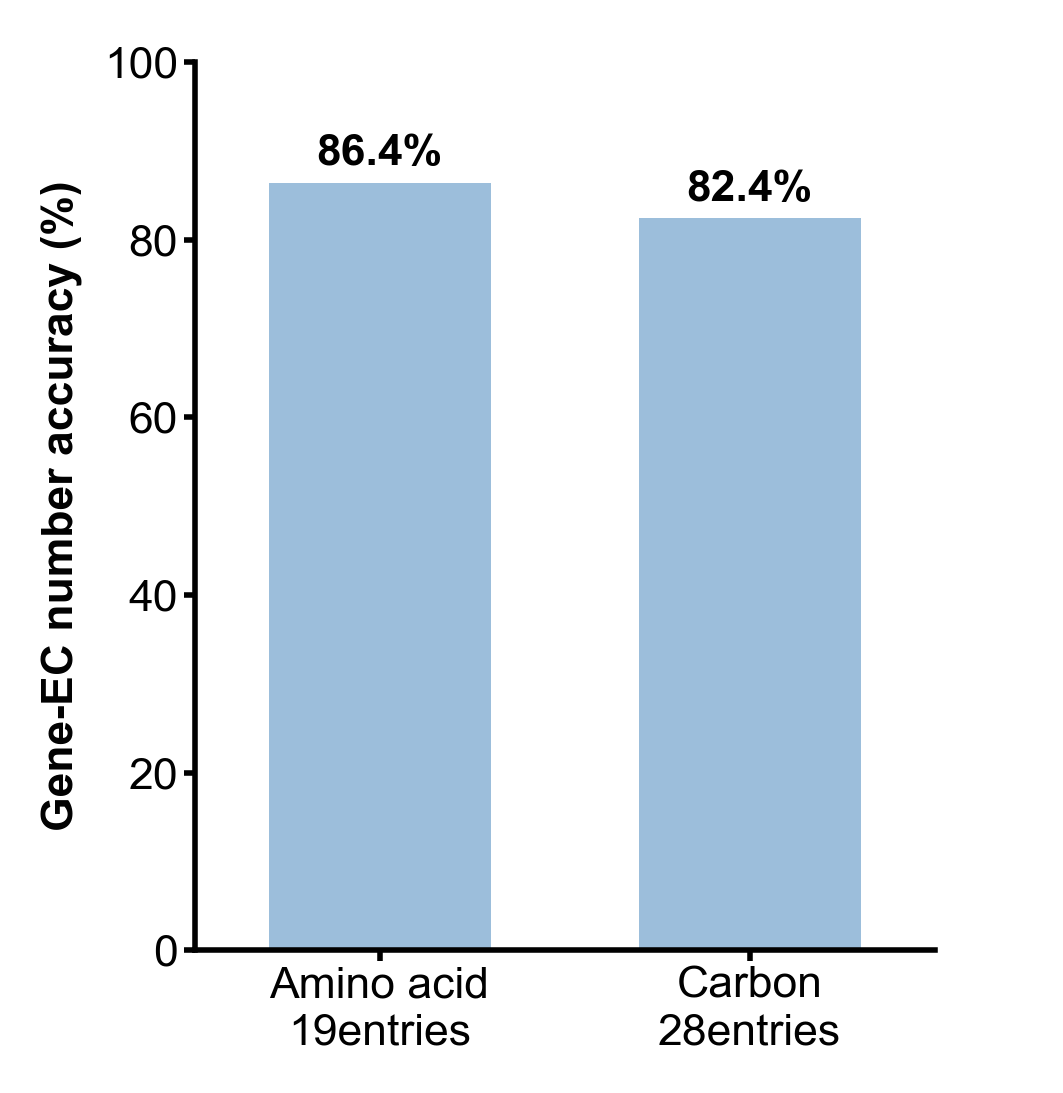

In [160]:
import matplotlib.pyplot as plt
import numpy as np

# 设置通用参数 - 增大图片尺寸，调整字体为8pt
plt.figure(figsize=(2.5, 3), dpi=400)  # 宽度和高度都翻倍
plt.rcParams.update({'font.size': 8})  # 字体改为8pt
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42

# 设置轴样式
plt.gca().spines['top'].set_linewidth(0)
plt.gca().spines['bottom'].set_linewidth(1)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['right'].set_linewidth(0)
plt.subplots_adjust(left=0.13, right=0.87, bottom=0.13, top=0.87)

# 示例数据（百分比）
ECnumber_acc = [86.4, 82.4]  # 百分比形式

# 设置每个部分的颜色
colors = ['#9cbedb']

# 设置柱状图的宽度
width = 0.6

# 创建 x 轴位置
x = np.arange(len(ECnumber_acc)) + 0.5  # 生成 x 轴坐标

# 绘制柱状图
bars1 = plt.bar(x, ECnumber_acc, width, color=colors[0], edgecolor='black', linewidth=0)

# 在柱子顶端加上值（百分比）- 字体改为8pt
plt.text(x[0], ECnumber_acc[0] + 1, f'{ECnumber_acc[0]:.1f}%', 
         ha='center', va='bottom', fontsize=8, fontweight='bold')  # 字体改为8pt
plt.text(x[1], ECnumber_acc[1] + 1, f'{ECnumber_acc[1]:.1f}%', 
         ha='center', va='bottom', fontsize=8, fontweight='bold')  # 字体改为8pt

# 设置坐标轴参数
plt.tick_params(axis='y', direction='out', width=1, which='both', length=2, pad=1)
plt.tick_params(axis='x', direction='out', width=1, which='both', length=2, pad=1)

# 设置坐标轴范围（百分比）
plt.ylim(0, 100)
plt.xlim(0, len(ECnumber_acc))

# 设置 x 轴标签 - 字体改为8pt
plt.xticks(x, ['Amino acid\n19entries', 'Carbon\n28entries'], rotation=0, fontsize=8)  # 字体改为8pt
plt.yticks(fontsize=8)  # 字体改为8pt

# 设置 y 轴标签（加上 %）- 字体改为8pt
plt.ylabel('Gene-EC number accuracy (%)', fontsize=8, fontweight='bold')

# 添加图例（目前无内容，如需添加图例可设置 label 参数）
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(
    handles[::-1], labels[::-1],
    fontsize=8,  # 字体改为8pt
    bbox_to_anchor=(1.15, 1.05), loc='upper right', frameon=False,
    handleheight=1,
    handletextpad=0.3,
)

plt.savefig(r"D:\Projects\Human_gene\Info_Extration\Picture\all_figs\fig2f.pdf", transparent = True, dpi=400, bbox_inches = 'tight')
# 显示图形
plt.show()

# kinetic

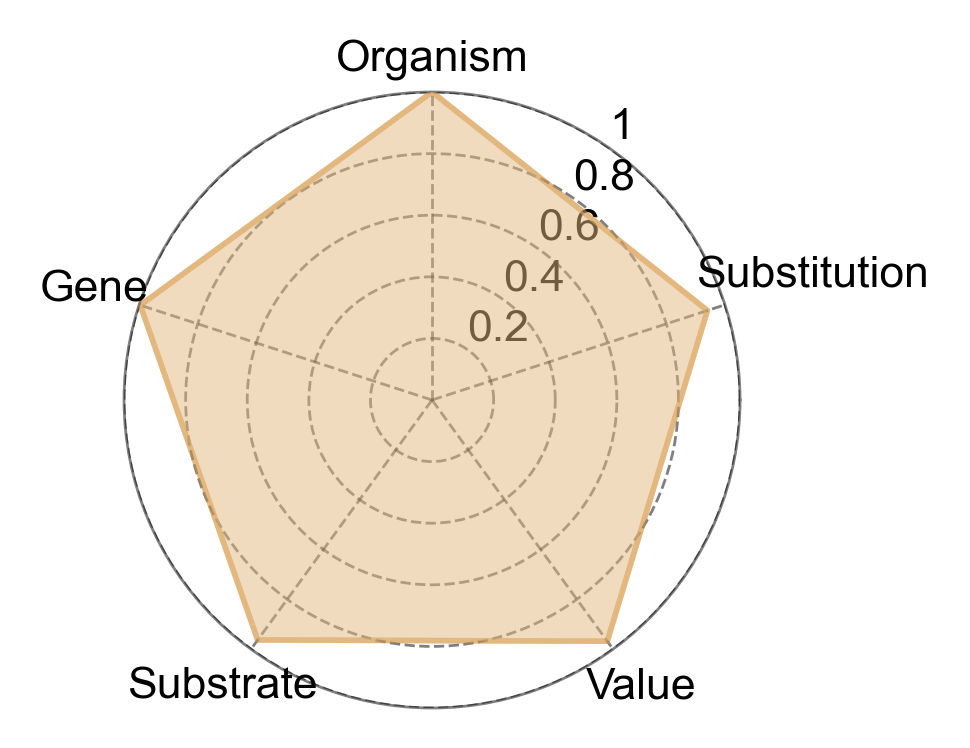

In [169]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
rag_score = [1, 0.996, 0.963, 0.968, 0.940]
labels = ['Organism', 'Gene', 'Substrate', 'Value', 'Substitution']

# 设置通用参数
plt.figure(figsize=(2, 2), dpi=400)
plt.rcParams.update({'font.size': 6})
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42

# 计算角度（确保五个点分别位于 [90°, 162°, 234°, 306°, 18°]）
num_vars = len(labels)
angles = np.array([90, 162, 234, 306, 18])  # 直接设置角度（单位：度）
angles = np.deg2rad(angles)  # 转换为弧度（matplotlib 需要弧度）

# 闭合雷达图
rag_score += rag_score[:1]  # 数据闭合
angles = np.append(angles, angles[0])  # 角度闭合

# 绘制雷达图
colors = ['#e3b87f', '#e3b87f', '#e3b87f']
plt.polar(angles, rag_score, color='#e3b87f', linewidth=1, alpha=1,zorder=-10)
plt.fill(angles, rag_score, color='#e3b87f', alpha=0.5,zorder=3)
plt.grid(linewidth=0.5, color='black', linestyle='-', alpha=1,zorder=10)

# 设置雷达图外圈的边框样式
ax = plt.gca()
ax.spines['polar'].set_linestyle('-')  # 确保边框仍然显示
ax.spines['polar'].set_linewidth(0.5)  # 设置边框粗细
ax.spines['polar'].set_color('black')  # 设置边框颜色
ax.spines['polar'].set_alpha(0.5)  # 设置边框颜色

# 设置雷达图的径向网格为虚线，并增加外圈的虚线效果
ax.grid(True, linestyle='--', linewidth=0.5, color='black',alpha=0.5)

# 设置标签
plt.thetagrids(np.degrees(angles[:-1]), labels,fontsize=8)

# 手动设置每个标签的坐标位置
label_positions = [
    (1.2, 0.15),  # Organism 的坐标 (x, y)
    (-0.1, 0.1),  # Gene 的坐标 (x, y)
    (-1.1, 0.1),  # Substrate 的坐标 (x, y)
    (-0.1, 0.1),  # Value 的坐标 (x, y)
    (1, -0.05),  # Substitution 的坐标 (x, y)
]

for label, pos in zip(ax.get_xticklabels(), label_positions):
    label.set_position(pos)  # 设置标签位置


# 设置 y 轴标签
# 设置 y 轴标签，并将其显示在 30 度的线上
ax.set_rlabel_position(55)  # 将径向刻度标签显示在 30 度的线上
plt.yticks([0.2, 0.4, 0.6, 0.8, 1], ["0.2", "0.4", "0.6", "0.8", "1"], color="black", size=8)
plt.ylim(0, 1)

# plt.xlabel('kcat',fontsize=8, fontweight='bold')

plt.savefig(r"D:\Projects\Human_gene\Info_Extration\Picture\all_figs\fig3a.pdf", transparent = True, dpi=400, bbox_inches = 'tight')
# 显示图形
plt.show()

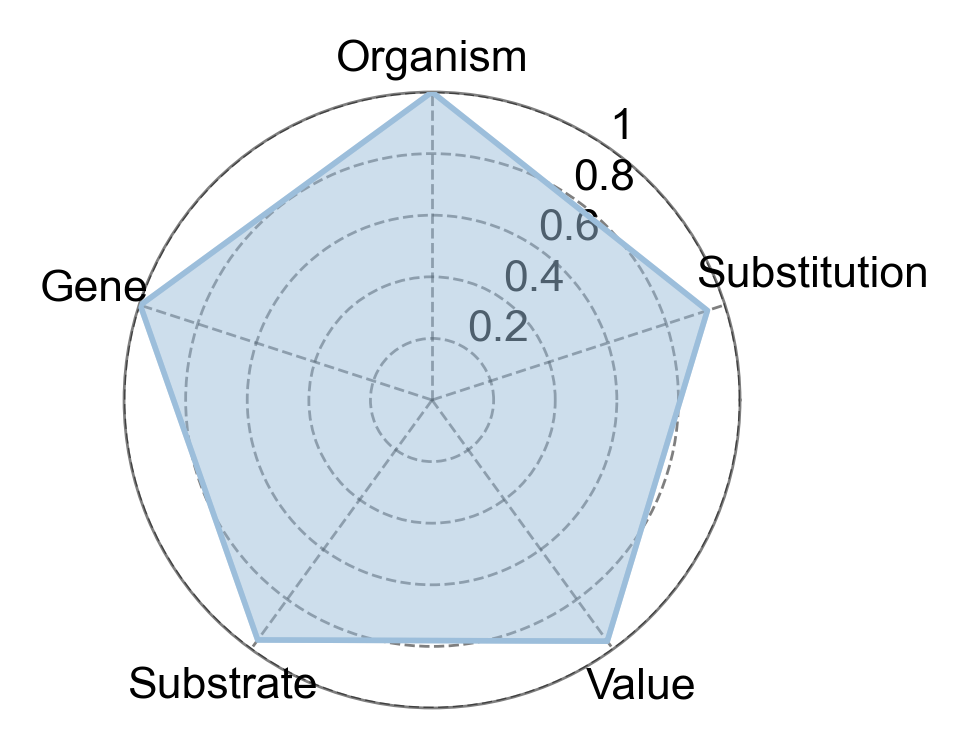

In [168]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
rag_score = [1, 0.996, 0.963, 0.968, 0.940]
labels = ['Organism', 'Gene', 'Substrate', 'Value', 'Substitution']

# 设置通用参数
plt.figure(figsize=(2, 2), dpi=400)
plt.rcParams.update({'font.size': 6})
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42

# 计算角度（确保五个点分别位于 [90°, 162°, 234°, 306°, 18°]）
num_vars = len(labels)
angles = np.array([90, 162, 234, 306, 18])  # 直接设置角度（单位：度）
angles = np.deg2rad(angles)  # 转换为弧度（matplotlib 需要弧度）

# 闭合雷达图
rag_score += rag_score[:1]  # 数据闭合
angles = np.append(angles, angles[0])  # 角度闭合

# 绘制雷达图
colors = ['#f08f92', '#9cbedb', '#a9d5a5']
plt.polar(angles, rag_score, color='#9cbedb', linewidth=1, alpha=1,zorder=10)
plt.fill(angles, rag_score, color='#9cbedb', alpha=0.5,zorder=3)
plt.grid(linewidth=0.5, color='black', linestyle='-', alpha=1,zorder=-1)

# 设置雷达图外圈的边框样式
ax = plt.gca()
ax.spines['polar'].set_linestyle('-')  # 确保边框仍然显示
ax.spines['polar'].set_linewidth(0.5)  # 设置边框粗细
ax.spines['polar'].set_color('black')  # 设置边框颜色
ax.spines['polar'].set_alpha(0.5)  # 设置边框颜色

# 设置雷达图的径向网格为虚线，并增加外圈的虚线效果
ax.grid(True, linestyle='--', linewidth=0.5, color='black',alpha=0.5)

# 设置标签
plt.thetagrids(np.degrees(angles[:-1]), labels,fontsize=8)

# 手动设置每个标签的坐标位置
label_positions = [
    (1.2, 0.15),  # Organism 的坐标 (x, y)
    (-0.1, 0.1),  # Gene 的坐标 (x, y)
    (-1.1, 0.1),  # Substrate 的坐标 (x, y)
    (-0.1, 0.1),  # Value 的坐标 (x, y)
    (1, -0.05),  # Substitution 的坐标 (x, y)
]

for label, pos in zip(ax.get_xticklabels(), label_positions):
    label.set_position(pos)  # 设置标签位置


# 设置 y 轴标签
# 设置 y 轴标签，并将其显示在 30 度的线上
ax.set_rlabel_position(55)  # 将径向刻度标签显示在 30 度的线上
plt.yticks([0.2, 0.4, 0.6, 0.8, 1], ["0.2", "0.4", "0.6", "0.8", "1"], color="black", size=8)
plt.ylim(0, 1)

# plt.xlabel('Km',fontsize=8, fontweight='bold')

plt.savefig(r"D:\Projects\Human_gene\Info_Extration\Picture\all_figs\fig3b.pdf", transparent = True, dpi=400, bbox_inches = 'tight')
# 显示图形
plt.show()

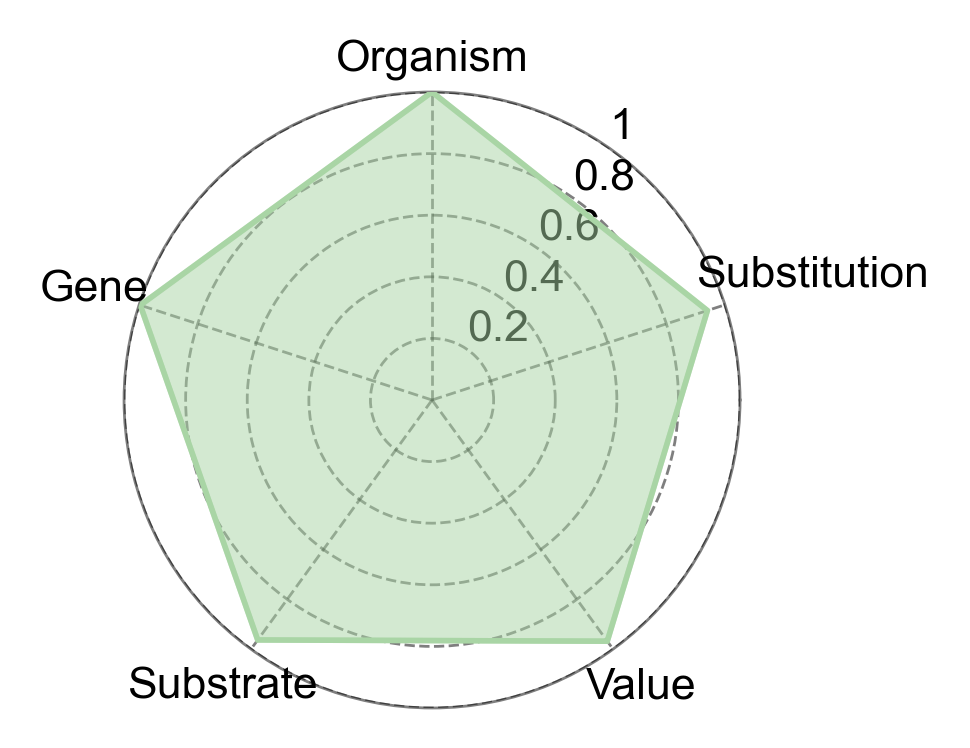

In [167]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
rag_score = [1, 0.996, 0.963, 0.968, 0.940]
labels = ['Organism', 'Gene', 'Substrate', 'Value', 'Substitution']

# 设置通用参数
plt.figure(figsize=(2, 2), dpi=400)
plt.rcParams.update({'font.size': 6})
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42

# 计算角度（确保五个点分别位于 [90°, 162°, 234°, 306°, 18°]）
num_vars = len(labels)
angles = np.array([90, 162, 234, 306, 18])  # 直接设置角度（单位：度）
angles = np.deg2rad(angles)  # 转换为弧度（matplotlib 需要弧度）

# 闭合雷达图
rag_score += rag_score[:1]  # 数据闭合
angles = np.append(angles, angles[0])  # 角度闭合

# 绘制雷达图
colors = ['#f08f92', '#9cbedb', '#a9d5a5']
plt.polar(angles, rag_score, color='#a9d5a5', linewidth=1, alpha=1,zorder=10)
plt.fill(angles, rag_score, color='#a9d5a5', alpha=0.5,zorder=3)
plt.grid(linewidth=0.5, color='black', linestyle='-', alpha=1,zorder=-1)

# 设置雷达图外圈的边框样式
ax = plt.gca()
ax.spines['polar'].set_linestyle('-')  # 确保边框仍然显示
ax.spines['polar'].set_linewidth(0.5)  # 设置边框粗细
ax.spines['polar'].set_color('black')  # 设置边框颜色
ax.spines['polar'].set_alpha(0.5)  # 设置边框颜色

# 设置雷达图的径向网格为虚线，并增加外圈的虚线效果
ax.grid(True, linestyle='--', linewidth=0.5, color='black',alpha=0.5)

# 设置标签
plt.thetagrids(np.degrees(angles[:-1]), labels,fontsize=8)

# 手动设置每个标签的坐标位置
label_positions = [
    (1.2, 0.15),  # Organism 的坐标 (x, y)
    (-0.1, 0.1),  # Gene 的坐标 (x, y)
    (-1.1, 0.1),  # Substrate 的坐标 (x, y)
    (-0.1, 0.1),  # Value 的坐标 (x, y)
    (1, -0.05),  # Substitution 的坐标 (x, y)
]

for label, pos in zip(ax.get_xticklabels(), label_positions):
    label.set_position(pos)  # 设置标签位置


# 设置 y 轴标签
# 设置 y 轴标签，并将其显示在 30 度的线上
ax.set_rlabel_position(55)  # 将径向刻度标签显示在 30 度的线上
plt.yticks([0.2, 0.4, 0.6, 0.8, 1], ["0.2", "0.4", "0.6", "0.8", "1"], color="black", size=8)
plt.ylim(0, 1)

# plt.xlabel('kcat/Km',fontsize=8, fontweight='bold')

plt.savefig(r"D:\Projects\Human_gene\Info_Extration\Picture\all_figs\fig3c.pdf", transparent = True, dpi=400, bbox_inches = 'tight')
# 显示图形
plt.show()

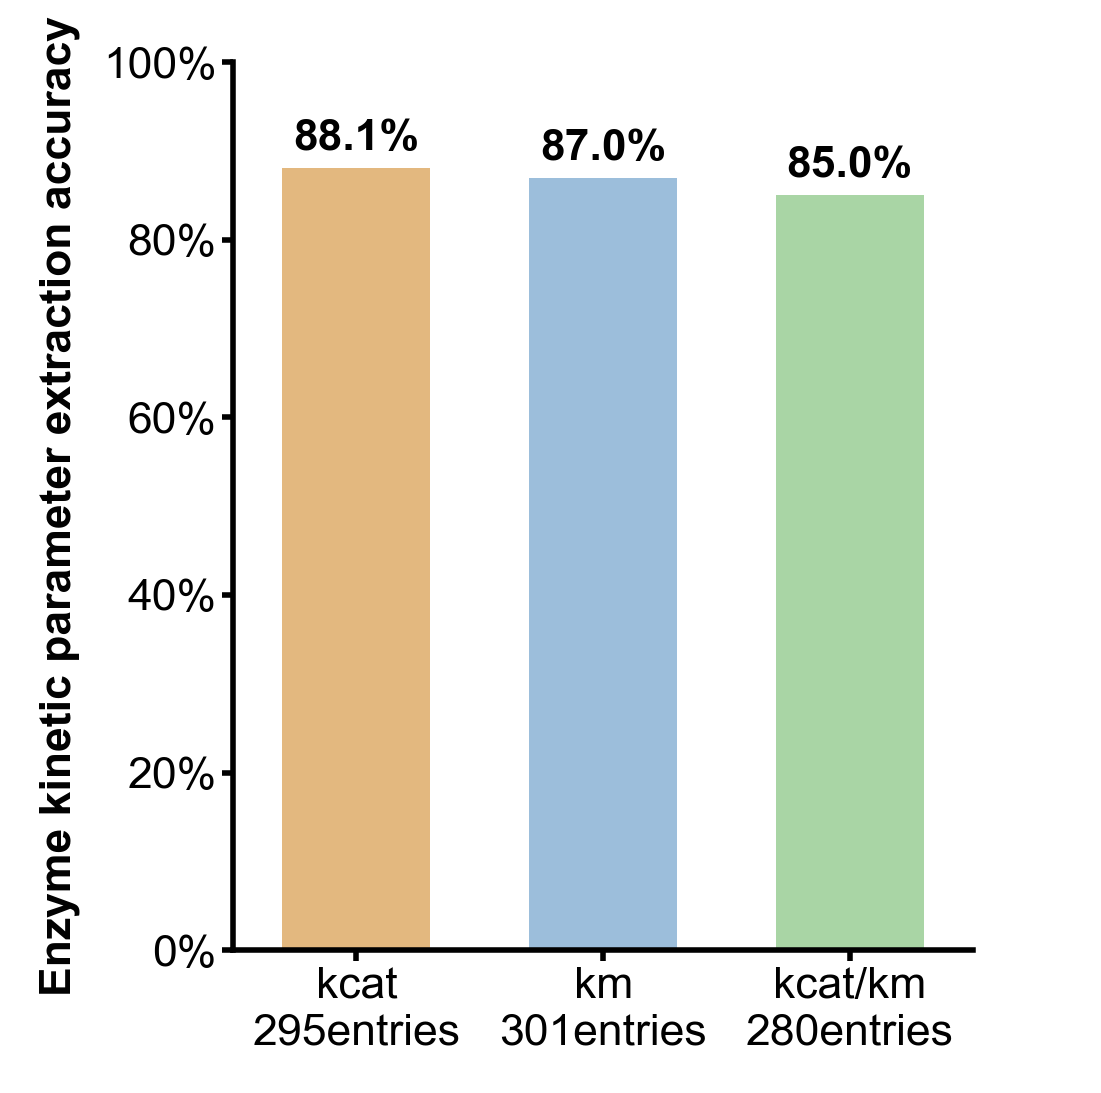

In [171]:
import matplotlib.pyplot as plt
import numpy as np

# 设置通用参数
plt.figure(figsize=(2.5, 3), dpi=400)
plt.rcParams.update({'font.size': 8})
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42

# 设置轴样式
plt.gca().spines['top'].set_linewidth(0)
plt.gca().spines['bottom'].set_linewidth(1)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['right'].set_linewidth(0)
plt.subplots_adjust(left=0.13, right=0.87, bottom=0.13, top=0.87)

# 示例数据（每组的三个组成部分）
kinetic_recall = [0.881, 0.870, 0.850]  

# 设置每个部分的颜色
colors = ['#e3b87f', '#9cbedb', '#a9d5a5']

# 设置柱状图的宽度
width = 0.6

# 创建 x 轴位置
x = np.arange(len(kinetic_recall)) + 0.5  # 生成 x 轴坐标

# 绘制柱状图
bars1 = plt.bar(x, kinetic_recall, width, color=colors, edgecolor='black', linewidth=0)

# 在柱子上方显示数值（转换为百分比）
plt.text(x[0], kinetic_recall[0] + 0.01, f'{kinetic_recall[0]*100:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
plt.text(x[1], kinetic_recall[1] + 0.01, f'{kinetic_recall[1]*100:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
plt.text(x[2], kinetic_recall[2] + 0.01, f'{kinetic_recall[2]*100:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

# 设置坐标轴参数
plt.tick_params(axis='y', direction='out', width=1, which='both', length=2, pad=1)
plt.tick_params(axis='x', direction='out', width=1, which='both', length=2, pad=1)

# 设置坐标轴范围
plt.ylim(0, 1)
plt.xlim(0, len(kinetic_recall))

# 设置 x 轴标签
plt.xticks(x, ['kcat\n295entries', 'km\n301entries', 'kcat/km\n280entries'], rotation=0, fontsize=8)

# 设置 y 轴标签和刻度（转换为百分比）
plt.yticks(np.arange(0, 1.1, 0.2), [f'{int(i*100)}%' for i in np.arange(0, 1.1, 0.2)], fontsize=8)

# 设置 y 轴标签
plt.ylabel('Enzyme kinetic parameter extraction accuracy', fontsize=8, fontweight='bold')

# 添加图例
# 获取当前图例的句柄和标签
handles, labels = plt.gca().get_legend_handles_labels()
# 颠倒顺序
plt.legend(
    handles[::-1], labels[::-1],
    fontsize=8, 
    bbox_to_anchor=(1.15, 1.05), loc='upper right', frameon=False,
    handleheight=1,  # 控制色块的高度
    handletextpad=0.3,  # 控制色块和文本之间的距离
)

plt.savefig(r"D:\Projects\Human_gene\Info_Extration\Picture\all_figs\fig3d.pdf", transparent=True, dpi=400, bbox_inches='tight')
# 显示图形
plt.show()

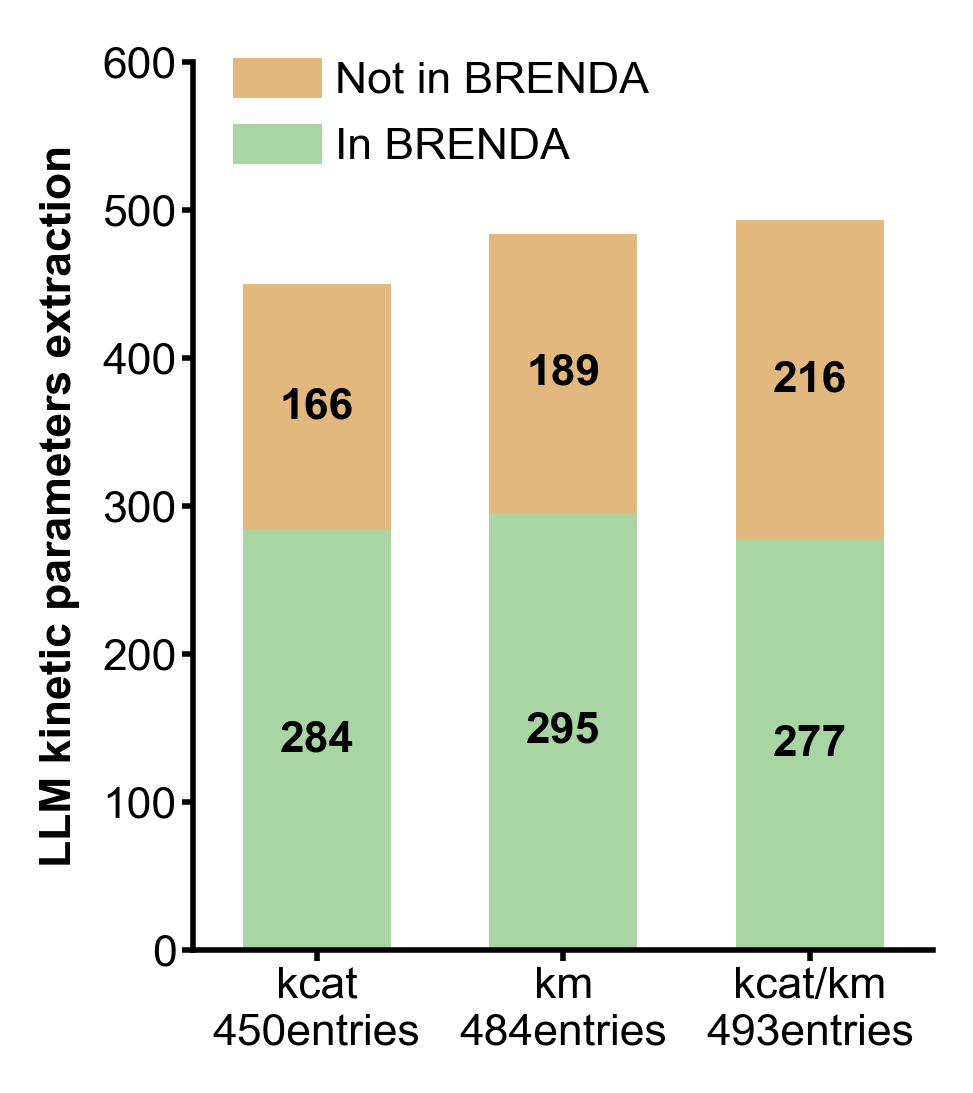

In [182]:
import matplotlib.pyplot as plt
import numpy as np

# 设置通用参数
plt.figure(figsize=(2.5, 3), dpi=400)
plt.rcParams.update({'font.size': 8})
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42

# 设置轴样式
plt.gca().spines['top'].set_linewidth(0)
plt.gca().spines['bottom'].set_linewidth(1)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['right'].set_linewidth(0)
plt.subplots_adjust(left=0.13, right=0.87, bottom=0.13, top=0.87)

# 示例数据（每组的两个组成部分）
value_inbrenda = [172+123-11, 177+124-6, 151+139-13]  
value_notinbrenda = [121+45, 142+47, 170+46]  

# 设置每个部分的颜色
colors = ['#a9d5a5', '#e3b87f']

# 设置柱状图的宽度
width = 0.6

# 创建 x 轴位置
x = np.arange(len(value_inbrenda)) + 0.5  # 生成 x 轴坐标

# 绘制堆积柱状图
bars1 = plt.bar(x, value_inbrenda, width, color=colors[0], edgecolor='black', linewidth=0, label='In BRENDA')
bars2 = plt.bar(x, value_notinbrenda, width, bottom=value_inbrenda, color=colors[1], edgecolor='black', linewidth=0, label='Not in BRENDA')

# 在柱子中间显示数值
for i in range(len(x)):
    # In BRENDA 数值
    plt.text(x[i], value_inbrenda[i] / 2, f'{value_inbrenda[i]}', ha='center', va='center', fontsize=8, fontweight='bold', color='black')
    # Not in BRENDA 数值
    plt.text(x[i], value_inbrenda[i] + value_notinbrenda[i] / 2, f'{value_notinbrenda[i]}', ha='center', va='center', fontsize=8, fontweight='bold', color='black')

# 设置坐标轴参数
plt.tick_params(axis='y', direction='out', width=1, which='both', length=2, pad=1)
plt.tick_params(axis='x', direction='out', width=1, which='both', length=2, pad=1)

# 设置坐标轴范围
plt.ylim(0, 600)
plt.xlim(0, len(value_inbrenda))

# 设置 x 轴标签
plt.xticks(x, ['kcat\n450entries', 'km\n484entries', 'kcat/km\n493entries'], rotation=0, fontsize=8)
plt.yticks(fontsize=8)

# 设置 y 轴标签
plt.ylabel('LLM kinetic parameters extraction', fontsize=8, fontweight='bold')

# 添加图例
# 获取当前图例的句柄和标签
handles, labels = plt.gca().get_legend_handles_labels()
# 颠倒顺序
plt.legend(
    handles[::-1], labels[::-1],
    fontsize=8, 
    bbox_to_anchor=(0.67, 1.05), loc='upper right', frameon=False,
    handleheight=1,  # 控制色块的高度
    handletextpad=0.3,  # 控制色块和文本之间的距离
)


plt.savefig(r"D:\Projects\Human_gene\Info_Extration\Picture\all_figs\fig3e.pdf", transparent = True, dpi=400, bbox_inches = 'tight')
# 显示图形
plt.show()


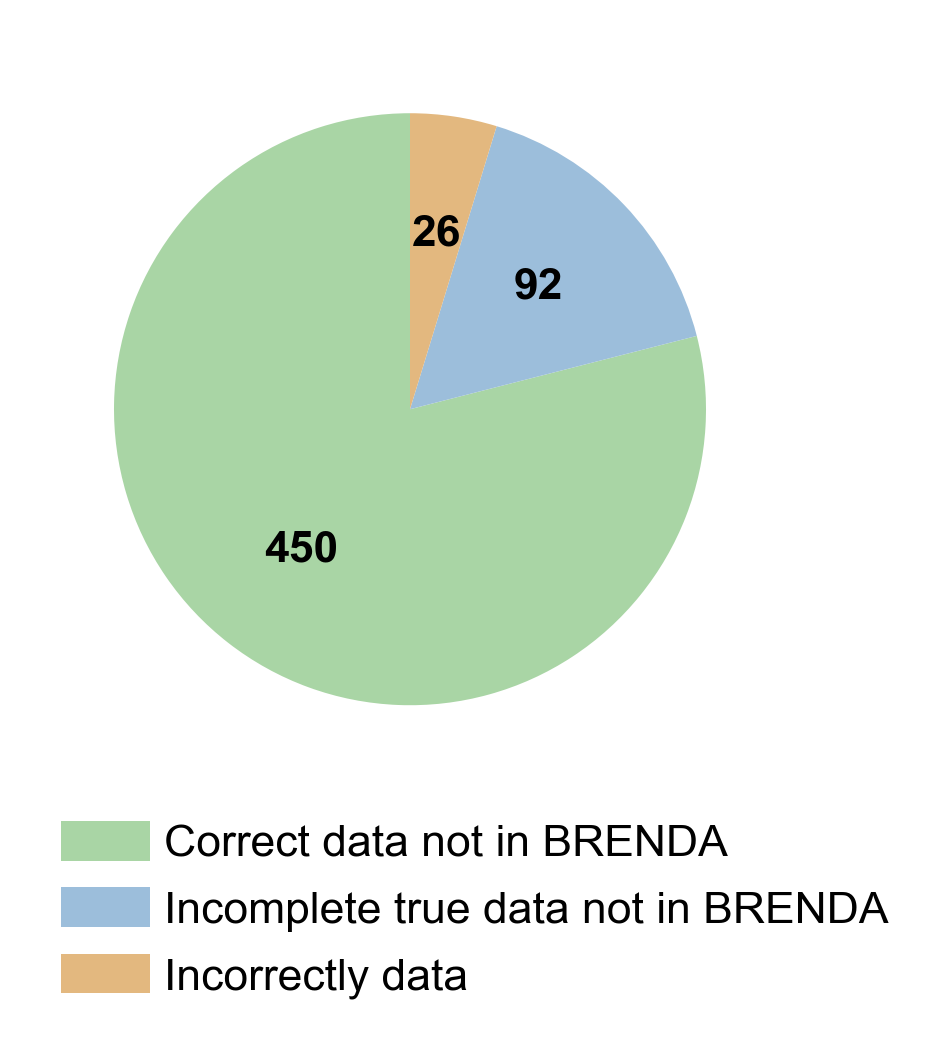

In [186]:
import matplotlib.pyplot as plt
import numpy as np

# 设置通用参数
plt.figure(figsize=(2.5, 3), dpi=400)
plt.rcParams.update({'font.size': 8})
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42

# 设置轴样式
plt.gca().spines['top'].set_linewidth(0)
plt.gca().spines['bottom'].set_linewidth(0)
plt.gca().spines['left'].set_linewidth(0)
plt.gca().spines['right'].set_linewidth(0)
plt.subplots_adjust(left=0.13, right=0.87, bottom=0.13, top=0.87)

# 示例数据（饼图的三个部分）
sizes = [451, 93, 27]
labels = ['Correct data not in BRENDA', 'Incomplete true data not in BRENDA', 'Incorrectly data']

# 设置每个部分的颜色
colors = ['#a9d5a5','#9cbedb','#e3b87f']

# 绘制饼图，显示数字而非比例
plt.pie(sizes, colors=colors, autopct=lambda p: f'{int(p * sum(sizes) / 100)}', startangle=90, 
        wedgeprops={'edgecolor': 'black', 'linewidth': 0}, textprops={'fontsize': 8, 'fontweight': 'bold'})



# 添加图例
plt.legend(
    labels=labels,  # 使用自定义的标签
    fontsize=8, 
    bbox_to_anchor=(1.2, -0.35), loc='lower right', frameon=False,
    handleheight=1,  # 控制色块的高度
    handletextpad=0.3,  # 控制色块和文本之间的距离
)

plt.savefig(r"D:\Projects\Human_gene\Info_Extration\Picture\all_figs\fig3f.pdf", transparent = True, dpi=400, bbox_inches = 'tight')
# 显示图形
plt.show()


# bionumbers

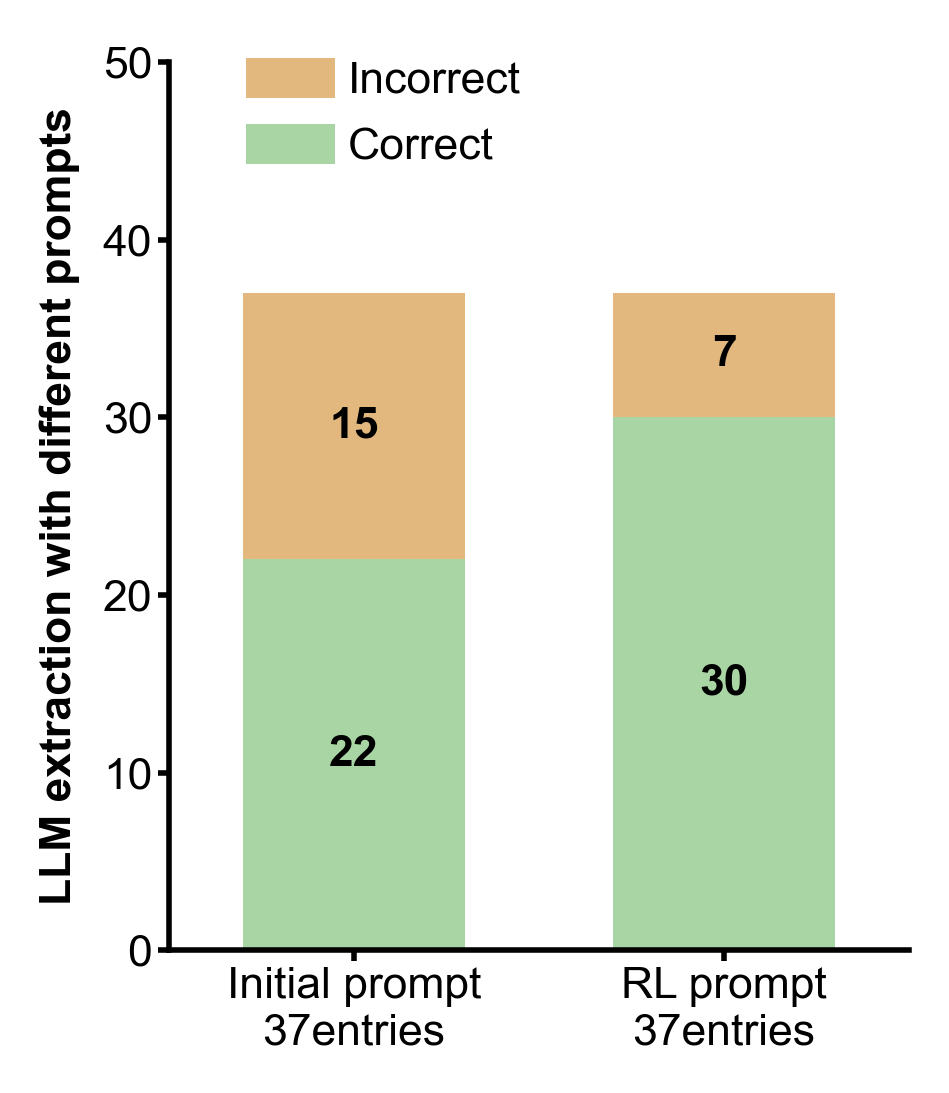

In [180]:
import matplotlib.pyplot as plt
import numpy as np

# 设置通用参数
plt.figure(figsize=(2.5, 3), dpi=400)
plt.rcParams.update({'font.size': 8})
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42

# 设置轴样式
plt.gca().spines['top'].set_linewidth(0)
plt.gca().spines['bottom'].set_linewidth(1)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['right'].set_linewidth(0)
plt.subplots_adjust(left=0.13, right=0.87, bottom=0.13, top=0.87)

# 示例数据（每组的三个组成部分）
Correct = [22, 30]  
InCorrect = [15, 7]  

# 设置每个部分的颜色
colors = ['#a9d5a5', '#e3b87f']

# 设置柱状图的宽度
width = 0.6

# 创建 x 轴位置
x = np.arange(len(Correct)) + 0.5  # 生成 x 轴坐标

# 绘制堆积柱状图
bars1 = plt.bar(x, Correct, width, color=colors[0], edgecolor='black', linewidth=0, label='Correct')
bars2 = plt.bar(x, InCorrect, width, bottom=Correct, color=colors[1], edgecolor='black', linewidth=0, label='Incorrect')
# 在柱子中间添加数字
for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
    height1 = bar1.get_height()
    height2 = bar2.get_height()
    # 在Correct柱的中间添加数字
    plt.text(bar1.get_x() + bar1.get_width() / 2, height1 / 2, str(int(height1)), ha='center', va='center', fontsize=8, color='black', fontweight='bold')
    # 在Incorrect柱的中间添加数字
    plt.text(bar2.get_x() + bar2.get_width() / 2, height1 + height2 / 2, str(int(height2)), ha='center', va='center', fontsize=8, color='black', fontweight='bold')

# 设置坐标轴参数
plt.tick_params(axis='y', direction='out', width=1, which='both', length=2, pad=1)
plt.tick_params(axis='x', direction='out', width=1, which='both', length=2, pad=1)

# 设置坐标轴范围
plt.ylim(0, 50)
plt.xlim(0, len(Correct))

# 设置 x 轴标签
plt.xticks(x, ['Initial prompt\n37entries', 'RL prompt\n37entries'], rotation=0, fontsize=8)
plt.yticks(fontsize=8)

# 设置 y 轴标签
plt.ylabel('LLM extraction with different prompts', fontsize=8, fontweight='bold')

# 添加图例
# 获取当前图例的句柄和标签
handles, labels = plt.gca().get_legend_handles_labels()
# 颠倒顺序
plt.legend(
    handles[::-1], labels[::-1],
    fontsize=8, 
    bbox_to_anchor=(0.05, 1.05), loc='upper left', frameon=False,
    # handlelength=1.5,  # 控制色块的长度
    handleheight=1,  # 控制色块的高度
    handletextpad=0.3,  # 控制色块和文本之间的距离
)
# 显示图形plt.show()
plt.savefig(r"D:\Projects\Human_gene\Info_Extration\Picture\all_figs\fig4b.pdf", transparent = True, dpi=400, bbox_inches = 'tight')

# Supplementary Figure1 year distribution


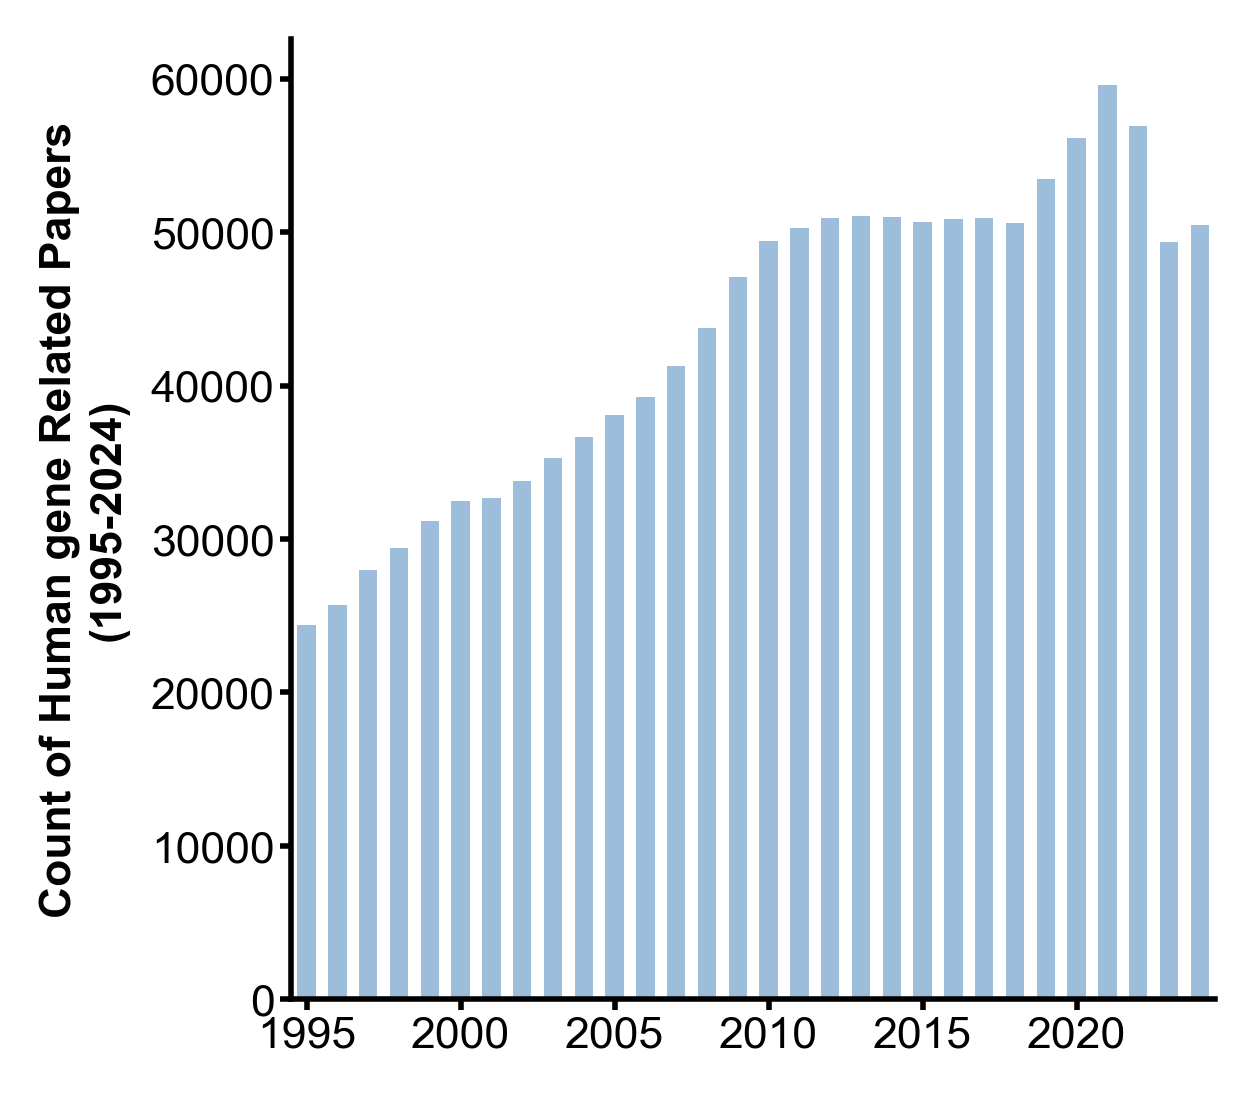

In [177]:
import matplotlib.pyplot as plt
import numpy as np

# 数据（年份正序排列）
years = list(range(1995, 2025))  # 1995 → 2024
counts = [
    24398, 25672, 27964, 29407, 31160, 32470, 32692, 33803, 35254, 36626,
    38115, 39231, 41261, 43730, 47048, 49437, 50298, 50931, 51052, 50998,
    50689, 50860, 50896, 50593, 53492, 56113, 59589, 56949, 49334, 50439
]
# 之前的数据是倒序的，这里颠倒回正序对应年份

# 设置图像尺寸和参数
plt.figure(figsize=(3, 3), dpi=400)
plt.rcParams.update({'font.size': 8})
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42

# 创建横轴位置
x = np.arange(len(years))

# 设置颜色
bar_color = '#9cbedb'  # 蓝绿色

# 绘图
bars = plt.bar(x, counts, width=0.6, color=bar_color, edgecolor='black', linewidth=0)

# 设置边框样式
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)

# 设置坐标轴范围
plt.ylim(0, max(counts) * 1.05)
plt.xlim(-0.5, len(years) - 0.5)

# 设置刻度样式
plt.tick_params(axis='y', direction='out', width=1, length=2, pad=1)
plt.tick_params(axis='x', direction='out', width=1, length=2, pad=1)

# 设置X轴标签（显示间隔年份）
plt.xticks(
    ticks=np.arange(0, len(years), 5),
    labels=[str(years[i]) for i in range(0, len(years), 5)],
    rotation=0,
    fontsize=8
)
plt.yticks(fontsize=8)

# 设置Y轴标签
plt.ylabel('Count of human gene related papers\n(1995-2024)', fontsize=8, fontweight='bold')

# 图像边距
plt.subplots_adjust(left=0.18, right=0.95, bottom=0.15, top=0.95)

# 保存图像（可选）
# plt.savefig('compact_human_gene_publications_reversed.png', dpi=600, bbox_inches='tight')

plt.savefig(r"D:\Projects\Human_gene\Info_Extration\Picture\all_figs\figs1a.pdf", transparent = True, dpi=400, bbox_inches = 'tight')
# 显示图形
plt.show()


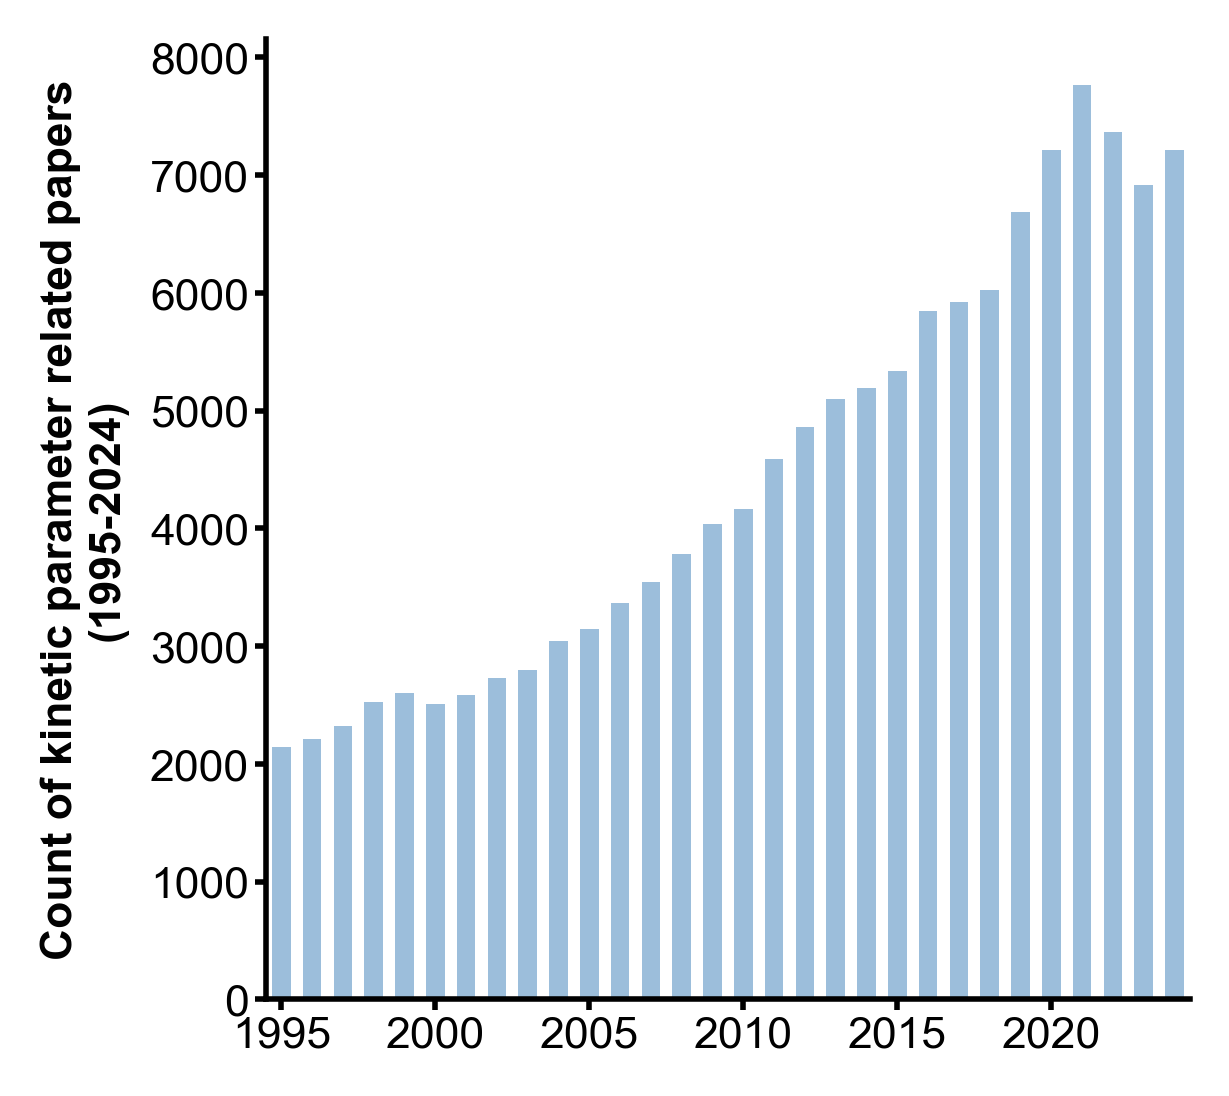

In [179]:
import matplotlib.pyplot as plt
import numpy as np

# 数据（年份正序排列）
years = list(range(1995, 2025))  # 1995 → 2024
counts = [2142, 2210, 2320, 2527, 2599, 2511, 2582, 2731, 2794, 3044, 3147, 3366, 3543, 3779, 4039, 4162, 4593, 4865, 5101, 5193, 5340, 5850, 5921, 6026, 6684, 7216, 7765, 7365, 6919, 7212]

# 之前的数据是倒序的，这里颠倒回正序对应年份

# 设置图像尺寸和参数
plt.figure(figsize=(3, 3), dpi=400)
plt.rcParams.update({'font.size': 8})
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42

# 创建横轴位置
x = np.arange(len(years))

# 设置颜色
bar_color = '#9cbedb'  # 蓝绿色

# 绘图
bars = plt.bar(x, counts, width=0.6, color=bar_color, edgecolor='black', linewidth=0)

# 设置边框样式
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)

# 设置坐标轴范围
plt.ylim(0, max(counts) * 1.05)
plt.xlim(-0.5, len(years) - 0.5)

# 设置刻度样式
plt.tick_params(axis='y', direction='out', width=1, length=2, pad=1)
plt.tick_params(axis='x', direction='out', width=1, length=2, pad=1)

# 设置X轴标签（显示间隔年份）
plt.xticks(
    ticks=np.arange(0, len(years), 5),
    labels=[str(years[i]) for i in range(0, len(years), 5)],
    rotation=0,
    fontsize=8
)
plt.yticks(fontsize=8)

# 设置Y轴标签
plt.ylabel('Count of kinetic parameter related papers\n(1995-2024)', fontsize=8, fontweight='bold')

# 图像边距
plt.subplots_adjust(left=0.18, right=0.95, bottom=0.15, top=0.95)

# 保存图像（可选）
# plt.savefig('compact_human_gene_publications_reversed.png', dpi=600, bbox_inches='tight')

plt.savefig(r"D:\Projects\Human_gene\Info_Extration\Picture\all_figs\figs1b.pdf", transparent = True, dpi=400, bbox_inches = 'tight')
# 显示图形
plt.show()


# Supplementary Figure2 Finetune result


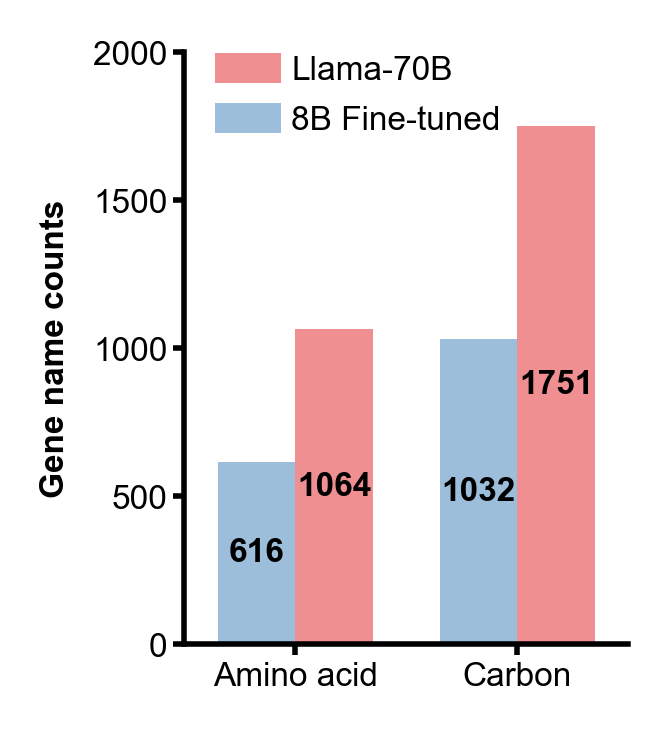

In [83]:
import matplotlib.pyplot as plt
import numpy as np

# 设置通用参数
plt.figure(figsize=(1.5, 2), dpi=400)
plt.rcParams.update({'font.size': 9})
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42

# 设置轴样式
plt.gca().spines['top'].set_linewidth(0)
plt.gca().spines['bottom'].set_linewidth(1)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['right'].set_linewidth(0)
plt.subplots_adjust(left=0.13, right=0.87, bottom=0.13, top=0.87)

# 示例数据（提取基因总数）
gene_counts = [616, 1064, 1032, 1751]  # 8B_Amino, 70B_Amino, 8B_Carbon, 70B_Carbon

# 设置每个部分的颜色
colors = ['#9cbedb', '#f08f92']

# 设置柱状图的宽度
width = 0.35  # 将柱宽度调整为更小的值

# 创建 x 轴位置
x = np.arange(2)  # 生成 x 轴坐标，两个位置

# 绘制柱状图 - 修改了x位置，使同组柱子紧贴
bars1 = plt.bar(x - width/2, [gene_counts[0], gene_counts[2]], width, color=colors[0], edgecolor='black', linewidth=0, label='8B Fine-tuned')
bars2 = plt.bar(x + width/2, [gene_counts[1], gene_counts[3]], width, color=colors[1], edgecolor='black', linewidth=0, label='Llama-70B')

# 设置坐标轴参数
plt.tick_params(axis='y', direction='out', width=1, which='both', length=2, pad=1)
plt.tick_params(axis='x', direction='out', width=1, which='both', length=2, pad=1)

# 设置坐标轴范围
plt.ylim(0, 2000)
plt.xlim(-0.5, 1.5)

# 设置 x 轴标签
plt.xticks(x, ['Amino acid', 'Carbon'], rotation=0, fontsize=6)
plt.yticks(fontsize=6)

# 设置 y 轴标签
plt.ylabel('Gene name counts', fontsize=6, fontweight='bold')

# 添加图例
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(
    handles[::-1], labels[::-1],
    fontsize=6, 
    bbox_to_anchor=(0.78, 1.05), loc='upper right', frameon=False,
    handleheight=1,
    handletextpad=0.3,
)

# 在柱子中间添加数字
for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
    height1 = bar1.get_height()
    height2 = bar2.get_height()
    plt.text(bar1.get_x() + bar1.get_width()/2, height1/2, f'{int(height1)}', ha='center', va='center', fontsize=6, fontweight='bold')
    plt.text(bar2.get_x() + bar2.get_width()/2, height2/2, f'{int(height2)}', ha='center', va='center', fontsize=6, fontweight='bold')

# 显示图形
plt.show()

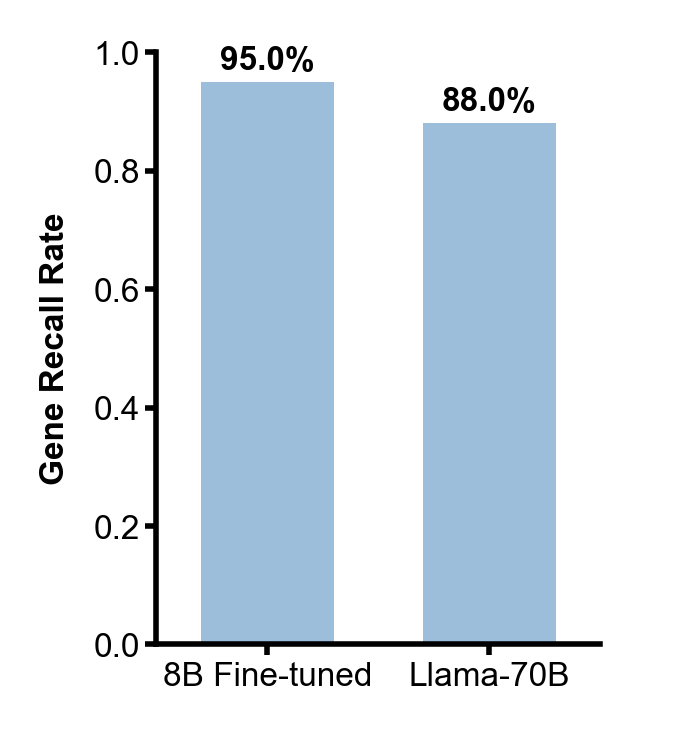

In [84]:
import matplotlib.pyplot as plt
import numpy as np

# 设置通用参数
plt.figure(figsize=(1.5, 2), dpi=400)
plt.rcParams.update({'font.size': 9})
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42

# 设置轴样式
plt.gca().spines['top'].set_linewidth(0)
plt.gca().spines['bottom'].set_linewidth(1)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['right'].set_linewidth(0)
plt.subplots_adjust(left=0.13, right=0.87, bottom=0.13, top=0.87)

# 示例数据（召回率）
recall_rate = [0.95, 0.88]  # 8B fine-tuned, 70B non-fine-tuned

# 设置每个部分的颜色
colors = ['#9cbedb', '#f08f92']

# 设置柱状图的宽度
width = 0.6

# 创建 x 轴位置
x = np.arange(len(recall_rate)) + 0.5  # 生成 x 轴坐标

# 绘制柱状图
bars = plt.bar(x, recall_rate, width, color=colors[0], edgecolor='black', linewidth=0)

# 在柱子顶端加上值（召回率）
plt.text(x[0], recall_rate[0] + 0.01, f'{recall_rate[0]*100:.1f}%', ha='center', va='bottom', fontsize=6, fontweight='bold')
plt.text(x[1], recall_rate[1] + 0.01, f'{recall_rate[1]*100:.1f}%', ha='center', va='bottom', fontsize=6, fontweight='bold')

# 设置坐标轴参数
plt.tick_params(axis='y', direction='out', width=1, which='both', length=2, pad=1)
plt.tick_params(axis='x', direction='out', width=1, which='both', length=2, pad=1)

# 设置坐标轴范围（百分比）
plt.ylim(0, 1)
plt.xlim(0, len(recall_rate))

# 设置 x 轴标签
plt.xticks(x, ['8B Fine-tuned', 'Llama-70B'], rotation=0, fontsize=6)
plt.yticks(fontsize=6)

# 设置 y 轴标签（加上 %）
plt.ylabel('Gene Recall Rate', fontsize=6, fontweight='bold')

# 添加图例（目前无内容，如需添加图例可设置 label 参数）
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(
    handles[::-1], labels[::-1],
    fontsize=6, 
    bbox_to_anchor=(1.15, 1.05), loc='upper right', frameon=False,
    handleheight=1,
    handletextpad=0.3,
)

# 显示图形
plt.show()
